# Notebook 08: Clustering features

K-means partitions rows into groups; one-hot membership lets a linear model fit a separate intercept per group, and distance to the assigned centroid adds a within-group gradient. We cluster two feature subsets:

- Geographic: latitude and longitude, which carves the map into regional markets
- Socioeconomic: income, rooms, and occupancy, which groups block types independent of location

The number of clusters is chosen from elbow and silhouette diagnostics; candidate features are screened with the residual scan, and each cluster set is admitted only if it improves cross-validated R² with Holm-Bonferroni significance.

## 1. Notebook set-up

In [1]:
import sys
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import ttest_rel
from statsmodels.stats.multitest import multipletests
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score

sys.path.insert(0, str(Path.cwd().resolve().parent / 'src'))
import featurely as fl

from config import (
    CLUSTER_GEO_FEATURES,
    CLUSTER_GEO_K,
    CLUSTER_SOCIO_FEATURES,
    CLUSTER_SOCIO_K,
    DATA_DIR,
    PIPELINE_COLORS,
    PIPELINE_RESULTS_PATH,
 )

## 2. Data loading

In [2]:
in_path = DATA_DIR / '07-aggregate-features.csv'

if not in_path.exists():
    raise FileNotFoundError(
        (f'Missing required input file: {in_path}. Run 07-aggregate-features.ipynb ' +
         'first to generate data/07-aggregate-features.csv.')
    )

housing_df = pd.read_csv(in_path)
print(f'Loaded: {in_path}')

Loaded: /workspaces/featurely/data/07-aggregate-features.csv


## 3. Choosing the number of clusters

Inertia always decreases with k, so we look for the elbow where the marginal gain flattens; silhouette measures how well separated the clusters are and typically peaks at a moderate k. The values selected from these diagnostics are recorded in `config.py` as `CLUSTER_GEO_K` and `CLUSTER_SOCIO_K`.

k =  2: inertia =       6240.8,  silhouette = 0.7513


k =  3: inertia =       4254.5,  silhouette = 0.6429


k =  4: inertia =       3301.7,  silhouette = 0.6019


k =  5: inertia =       2436.4,  silhouette = 0.5802


k =  6: inertia =       1869.3,  silhouette = 0.5668


...

k =  8: inertia =       1416.5,  silhouette = 0.5169


k =  9: inertia =       1244.7,  silhouette = 0.5000


k = 10: inertia =       1128.1,  silhouette = 0.5020


k = 11: inertia =       1015.4,  silhouette = 0.4718


k = 12: inertia =        895.7,  silhouette = 0.4906


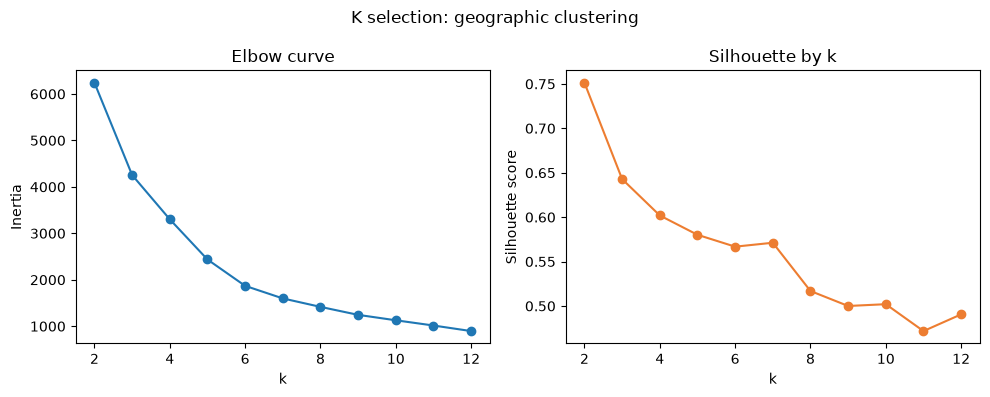

In [3]:
geo_silhouettes = fl.plot_kmeans_selection(
    housing_df,
    CLUSTER_GEO_FEATURES,
    k_range=range(2, 13),
    title='K selection: geographic clustering',
 )

k =  2: inertia =      40919.5,  silhouette = 0.3086


k =  3: inertia =      29142.2,  silhouette = 0.3241


k =  4: inertia =      23511.6,  silhouette = 0.2940


k =  5: inertia =      20788.1,  silhouette = 0.2615


k =  6: inertia =      18625.1,  silhouette = 0.2543


...

k =  8: inertia =      15530.5,  silhouette = 0.2584


k =  9: inertia =      14311.8,  silhouette = 0.2479


k = 10: inertia =      13288.9,  silhouette = 0.2519


k = 11: inertia =      12419.1,  silhouette = 0.2540


k = 12: inertia =      11752.9,  silhouette = 0.2484


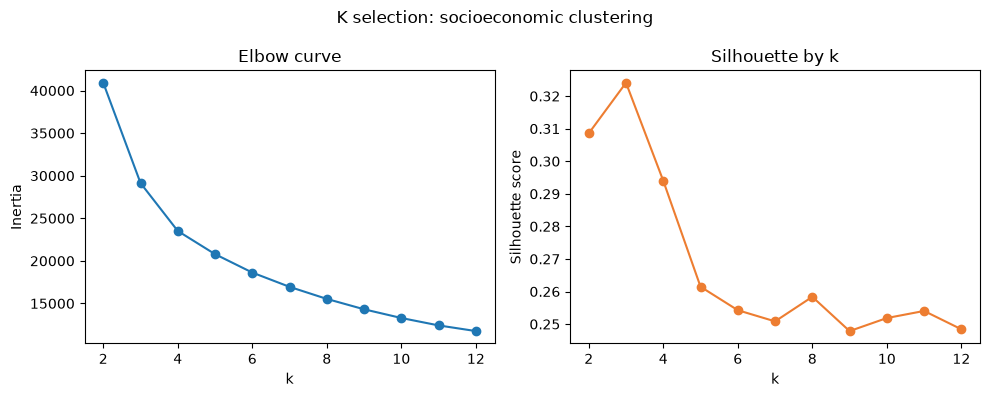

In [4]:
socio_silhouettes = fl.plot_kmeans_selection(
    housing_df,
    CLUSTER_SOCIO_FEATURES,
    k_range=range(2, 13),
    title='K selection: socioeconomic clustering',
 )

## 4. Cluster membership candidates

Each candidate set contains one-hot membership indicators plus the distance from each row to its assigned centroid in scaled feature space. The map below shows the geographic clusters; they should recover recognizable regional markets.

Geographic candidates:    9 columns
Socioeconomic candidates: 6 columns


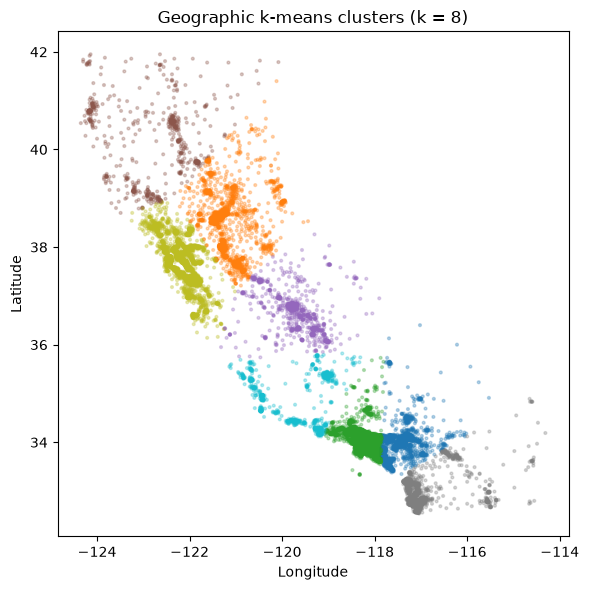

In [5]:
geo_clusters = fl.compute_kmeans_features(
    housing_df, CLUSTER_GEO_FEATURES, k=CLUSTER_GEO_K, prefix='geoclust'
 )

socio_clusters = fl.compute_kmeans_features(
    housing_df, CLUSTER_SOCIO_FEATURES, k=CLUSTER_SOCIO_K, prefix='socioclust'
 )

print(f'Geographic candidates:    {geo_clusters.shape[1]} columns')
print(f'Socioeconomic candidates: {socio_clusters.shape[1]} columns')

# Recover integer labels from the one-hot columns to color the map.
geo_onehot_cols = [c for c in geo_clusters.columns if c != 'geoclust_centroid_dist']
geo_labels = geo_clusters[geo_onehot_cols].values.argmax(axis=1)

fig, ax = plt.subplots(figsize=(6, 6))
scatter = ax.scatter(
    housing_df['Longitude'], housing_df['Latitude'],
    c=geo_labels, cmap='tab10', s=4, alpha=0.3
)
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title(f'Geographic k-means clusters (k = {CLUSTER_GEO_K})')
plt.tight_layout()
plt.show()

## 5. Residual scan of cluster candidates

Baseline R2 (in-sample): 0.7198

              geoclust_0: r = -0.0709,  p = 0.0000
              geoclust_1: r = +0.0405,  p = 0.0000
              geoclust_2: r = +0.0268,  p = 0.0001
              geoclust_3: r = -0.0299,  p = 0.0000
              geoclust_4: r = -0.0458,  p = 0.0000
              geoclust_5: r = +0.0146,  p = 0.0359
              geoclust_6: r = +0.0082,  p = 0.2375
              geoclust_7: r = +0.0119,  p = 0.0879
  geoclust_centroid_dist: r = +0.0654,  p = 0.0000
            socioclust_0: r = +0.0187,  p = 0.0072
            socioclust_1: r = -0.0401,  p = 0.0000
            socioclust_2: r = +0.0285,  p = 0.0000
            socioclust_3: r = -0.0158,  p = 0.0234
            socioclust_4: r = +0.0260,  p = 0.0002
socioclust_centroid_dist: r = +0.0393,  p = 0.0000


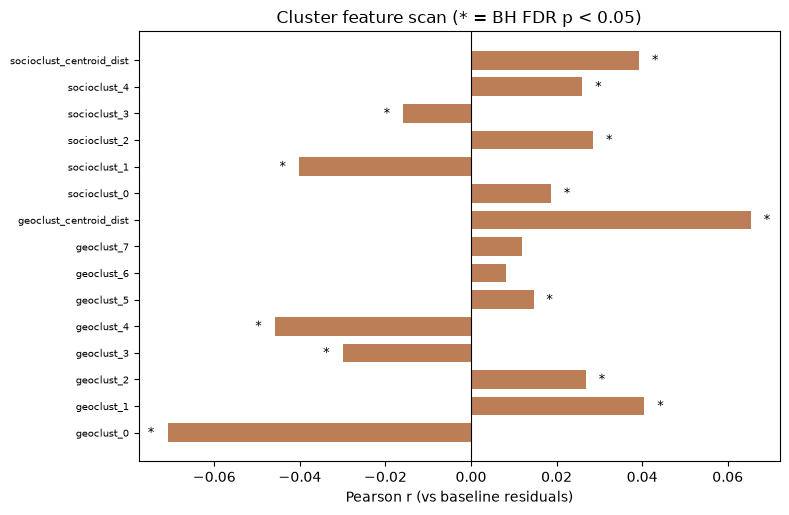

In [6]:
cluster_candidates = pd.concat([geo_clusters, socio_clusters], axis=1)

scan_results = fl.run_candidate_scan(housing_df, cluster_candidates)

sig_dict = fl.plot_candidate_scan(
    scan_results,
    title='Cluster feature scan (* = BH FDR p < 0.05)',
    color=PIPELINE_COLORS.get('+ clusters', '#9e480e'),
 )

## 6. Cross-validated comparison of cluster sets

One-hot cluster indicators act jointly, so we admit whole sets rather than individual columns: baseline versus geographic, socioeconomic, and both, with paired t-tests and Holm-Bonferroni correction.

In [7]:
x_base = housing_df.drop('MedHouseVal', axis=1)
y = housing_df['MedHouseVal']

cluster_sets = {
    'baseline': x_base,
    '+ geo clusters': pd.concat([x_base, geo_clusters], axis=1),
    '+ socio clusters': pd.concat([x_base, socio_clusters], axis=1),
    '+ both': pd.concat([x_base, geo_clusters, socio_clusters], axis=1),
}

cv_cluster_results = {}

for label, x in cluster_sets.items():
    scores = cross_val_score(LinearRegression(), x, y, cv=10, scoring='r2')
    cv_cluster_results[label] = scores
    print(f'{label:>18}: mean R² = {scores.mean():.4f} ± {scores.std():.4f}')

          baseline: mean R² = 0.6199 ± 0.0851


    + geo clusters: mean R² = 0.5929 ± 0.1018


  + socio clusters: mean R² = 0.6222 ± 0.0851


            + both: mean R² = 0.5955 ± 0.1013


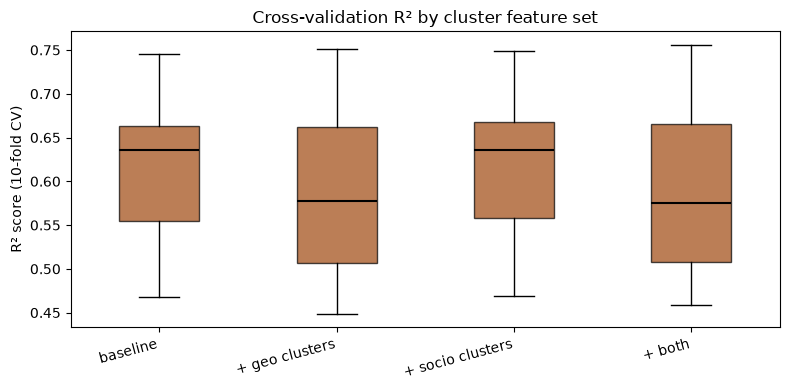


Paired t-tests vs baseline (Holm-Bonferroni; * = p_corr < 0.05):
  baseline vs   + geo clusters: t = +1.5465,  p_raw = 0.1564,  p_corr = 0.3128
  baseline vs + socio clusters: t = -2.0389,  p_raw = 0.0719,  p_corr = 0.2157
  baseline vs           + both: t = +1.4284,  p_raw = 0.1870,  p_corr = 0.3128


In [8]:
fig, ax = plt.subplots(figsize=(8, 4))

bp = ax.boxplot(
    cv_cluster_results.values(),
    tick_labels=list(cv_cluster_results.keys()),
    patch_artist=True
)

for patch in bp['boxes']:
    patch.set_facecolor(PIPELINE_COLORS.get('+ clusters', '#9e480e'))
    patch.set_alpha(0.7)

for median in bp['medians']:
    median.set(color='black', linewidth=1.5)

ax.set_title('Cross-validation R² by cluster feature set')
ax.set_ylabel('R² score (10-fold CV)')
plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.show()

baseline_scores = cv_cluster_results['baseline']
paired_keys = [k for k in cv_cluster_results if k != 'baseline']
t_stats, p_raws = [], []

for k in paired_keys:
    t_stat, p_raw = ttest_rel(baseline_scores, cv_cluster_results[k])
    t_stats.append(t_stat)
    p_raws.append(p_raw)

reject, p_corrected, _, _ = multipletests(p_raws, alpha=0.05, method='holm')

print('\nPaired t-tests vs baseline (Holm-Bonferroni; * = p_corr < 0.05):')
improved = {}

for k, t_stat, p_raw, p_corr, rej in zip(paired_keys, t_stats, p_raws, p_corrected, reject):
    marker = ' *' if rej else ''
    print(f'  baseline vs {k:>16}: t = {t_stat:+.4f},  p_raw = {p_raw:.4f},  p_corr = {p_corr:.4f}{marker}')
    improved[k] = bool(rej) and cv_cluster_results[k].mean() > baseline_scores.mean()

## 7. Add selected cluster features

The best-performing significant set wins. When '+ both' is the top significant configuration, both sets enter the frame; otherwise only the winning single set is added.

In [9]:
set_frames = {
    '+ geo clusters': [geo_clusters],
    '+ socio clusters': [socio_clusters],
    '+ both': [geo_clusters, socio_clusters],
}

best_label = None
best_mean = baseline_scores.mean()

for label in set_frames:
    if improved.get(label, False) and cv_cluster_results[label].mean() > best_mean:
        best_label = label
        best_mean = cv_cluster_results[label].mean()

if best_label is not None:
    housing_df = pd.concat([housing_df] + set_frames[best_label], axis=1)
    n_added = sum(f.shape[1] for f in set_frames[best_label])
    print(f'Added {n_added} cluster feature(s) from set: {best_label}')

else:
    print('No cluster set produced a significant improvement; no changes made.')

No cluster set produced a significant improvement; no changes made.


## 8. Performance evaluation

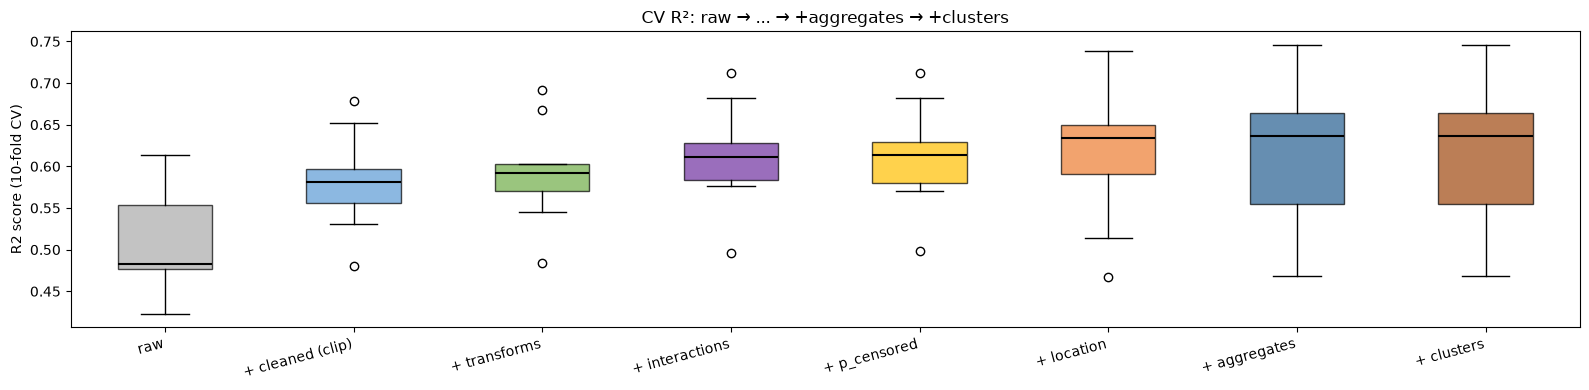

                      raw: mean R2 = 0.5110 ± 0.0593  (+0.00% vs raw)
         + cleaned (clip): mean R2 = 0.5811 ± 0.0536  (+13.71% vs raw)
             + transforms: mean R2 = 0.5923 ± 0.0551  (+15.90% vs raw)
           + interactions: mean R2 = 0.6122 ± 0.0561  (+19.81% vs raw)
             + p_censored: mean R2 = 0.6120 ± 0.0564  (+19.76% vs raw)
               + location: mean R2 = 0.6201 ± 0.0786  (+21.34% vs raw)
             + aggregates: mean R2 = 0.6199 ± 0.0851  (+21.31% vs raw)
               + clusters: mean R2 = 0.6199 ± 0.0851  (+21.31% vs raw)


In [10]:
results_df = fl.add_pipeline_step(
    None,
    '+ clusters',
    housing_df.drop('MedHouseVal', axis=1),
    housing_df['MedHouseVal'],
    color=PIPELINE_COLORS.get('+ clusters', '#9e480e'),
    results_path=PIPELINE_RESULTS_PATH,
 )

fl.plot_pipeline_steps(
    results_df,
    title='CV R²: raw → ... → +aggregates → +clusters',
    results_path=PIPELINE_RESULTS_PATH,
 )

## 9. Save output

In [11]:
out_path = DATA_DIR / '08-clustering.csv'
housing_df.to_csv(out_path, index=False)
print(f'Saved: {out_path}')

Saved: /workspaces/featurely/data/08-clustering.csv
